# Catchment Delineation — Step-by-step Walkthrough

This notebook walks through every step of the catchment delineation pipeline
in `eoflow/catchment.py`, using a real pour point on the **River Exe** near
Thorverton gauging station, Devon.

---

### Pipeline

```
Pour point (lon, lat)
      │
      ▼
 1. Load DEM  ──────────────────────────► inspect metadata, plot raw elevation
      │
      ▼
 2. Fill pits  ─────────────────────────► remove single-cell sinks
      │
      ▼
 3. Fill depressions  ──────────────────► remove multi-cell sinks
      │
      ▼
 4. Resolve flats  ─────────────────────► add micro-gradient across flat areas
      │
      ▼
 5. Flow direction (D8)  ───────────────► each cell points to steepest neighbour
      │
      ▼
 6. Flow accumulation  ─────────────────► count upstream cells (= stream network)
      │
      ▼
 7. Snap pour point  ───────────────────► move to nearest high-accumulation cell
      │
      ▼
 8. Delineate catchment  ───────────────► trace all cells draining to snap point
      │
      ▼
 9. Vectorise → Polygon  ───────────────► polygonise the boolean mask
      │
      ▼
10. Folium maps  ───────────────────────► interactive visualisation
```

> **NumPy 2.x note** — pysheds 0.4 has a NEP-50 incompatibility where
> `np.can_cast(nodata, dtype, casting='safe')` raises `TypeError` for
> Python scalars.  After `fill_pits` the DEM is upcast to `float64`; its
> nodata cannot be safely represented in the integer `flowdir`/`accumulation`
> arrays or the boolean `catchment` array.  The fix is to pass explicit
> NumPy scalar `nodata_out` values:
> - `nodata_out=np.int64(0)` for `flowdir` and `accumulation`
> - `nodata_out=np.bool_(False)` for `catchment`


## 0. Imports & configuration

In [1]:
from __future__ import annotations

import math
import sys
import time
import warnings
from pathlib import Path

import folium
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from pysheds.grid import Grid
from shapely.geometry import LineString, Point, mapping, shape

warnings.filterwarnings("ignore")

try:
    REPO_ROOT = Path(__file__).resolve().parent.parent
except NameError:
    REPO_ROOT = Path.cwd().parent

if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

from eoflow.catchment import (
    _delineate_catchment_core,
    compute_flow_accumulation,
    delineate_catchment,
    delineate_catchment_with_metadata,
)


In [2]:
# ── Configuration ─────────────────────────────────────────────────────────
DEM_PATH = REPO_ROOT / "data" / "devon_dem.tif"
assert DEM_PATH.exists(), f"DEM not found: {DEM_PATH}"

# River Exe at Thorverton gauging station, Devon
# Point(x=lon, y=lat) — Shapely convention: x first
POUR_LON, POUR_LAT = -3.4950, 50.8140
POUR_POINT = Point(POUR_LON, POUR_LAT)

# D8 direction map  (N, NE, E, SE, S, SW, W, NW)
DIRMAP = (64, 128, 1, 2, 4, 8, 16, 32)

# Cells upstream needed to be considered part of the stream network.
# At ~31 m/pixel this is roughly 5000 * 900 m² ≈ 4.5 km² of upstream area.
FLOW_ACC_THRESHOLD = 5000

print(f"DEM        : {DEM_PATH}")
print(f"Pour point : lon={POUR_LON}, lat={POUR_LAT}")
print(f"Threshold  : {FLOW_ACC_THRESHOLD:,} upstream cells")


DEM        : /home/finley/Work/RDS/projects/enforce/repos/eoflow/data/devon_dem.tif
Pour point : lon=-3.495, lat=50.814
Threshold  : 5,000 upstream cells


---
## 1. Load the DEM

We open the file twice:
- **rasterio** — for metadata (CRS, bounds, transform, nodata) and the raw array.
- **pysheds** — for the `Grid` and `Raster` objects needed by the conditioning
  and flow-routing steps.


In [3]:
with rasterio.open(DEM_PATH) as src:
    dem_array     = src.read(1).astype(float)
    dem_nodata    = src.nodata
    dem_crs       = src.crs
    dem_transform = src.transform
    dem_bounds    = src.bounds

# Mask nodata for plotting
dem_plot = np.where(dem_array == dem_nodata, np.nan, dem_array)
extent   = [dem_bounds.left, dem_bounds.right, dem_bounds.bottom, dem_bounds.top]

print(f"Shape   : {dem_array.shape}")
print(f"CRS     : {dem_crs}")
print(f"Bounds  : {dem_bounds}")
print(f"Nodata  : {dem_nodata}  (dtype: {type(dem_nodata).__name__})")
print(f"Elev range: {np.nanmin(dem_plot):.0f} – {np.nanmax(dem_plot):.0f} m")


Shape   : (3757, 6457)
CRS     : EPSG:4326
Bounds  : BoundingBox(left=-4.680694444421221, bottom=50.202916666665374, right=-2.8870833333098718, top=51.24652777777662)
Nodata  : -32768.0  (dtype: float)
Elev range: -37 – 617 m


In [4]:
grid = Grid.from_raster(str(DEM_PATH))
dem  = grid.read_raster(str(DEM_PATH))
print(f"pysheds Grid bbox : {grid.bbox}")
print(f"dem.dtype         : {dem.dtype}")
print(f"dem.nodata        : {dem.nodata!r}  (type: {type(dem.nodata).__name__})")


pysheds Grid bbox : (-4.680694444421221, 50.202916666665374, -2.8870833333098718, 51.24652777777662)
dem.dtype         : int16
dem.nodata        : np.int16(-32768)  (type: int16)


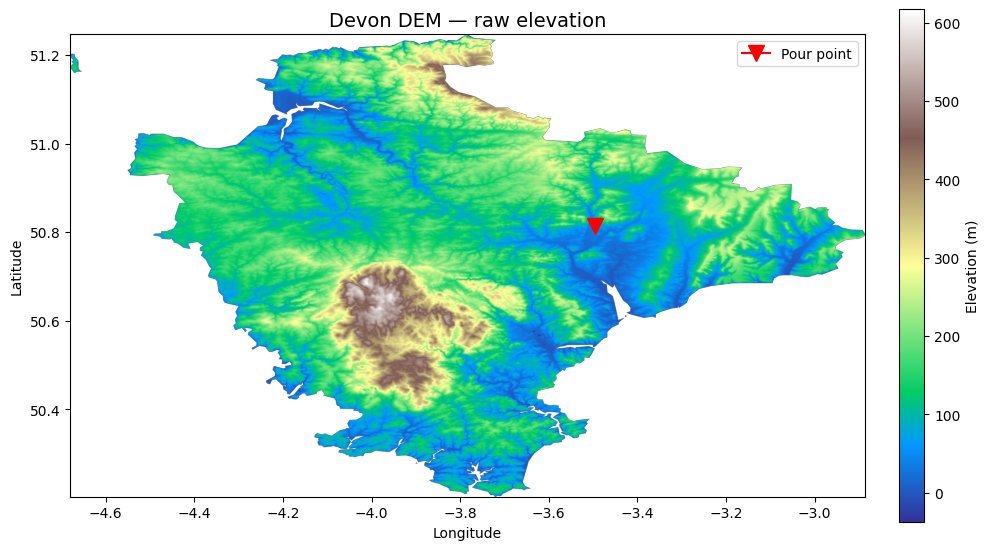

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(dem_plot, extent=extent, cmap="terrain", origin="upper")
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04, label="Elevation (m)")
ax.plot(POUR_LON, POUR_LAT, marker="v", color="red", markersize=11,
        zorder=5, label="Pour point")
ax.set_title("Devon DEM — raw elevation", fontsize=14)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.legend(); plt.tight_layout(); plt.show()


---
## 2. Hydrological conditioning

The DEM must be conditioned before flow routing.  Each step removes artefacts
that would otherwise trap or misdirect water:

| Step | Method | Purpose |
|------|--------|---------|
| **Fill pits** | `grid.fill_pits` | Remove isolated single-cell sinks |
| **Fill depressions** | `grid.fill_depressions` | Remove multi-cell enclosed basins |
| **Resolve flats** | `grid.resolve_flats` | Add a tiny gradient across zero-slope areas |

> **nodata note** — `fill_pits` upcasts the DEM to `float64` and carries
> `nodata=-32768` as a float.  Downstream integer steps (`flowdir`,
> `accumulation`) and boolean steps (`catchment`) cannot store a float nodata
> under NumPy 2.x (NEP 50).  We supply `nodata_out=np.int64(0)` /
> `np.bool_(False)` explicitly for each affected step.


In [6]:
# ── Step 1: fill pits ─────────────────────────────────────────────────────
pit_filled = grid.fill_pits(dem)
print(f"After fill_pits    : dtype={pit_filled.dtype}  nodata={pit_filled.nodata!r}")

# ── Step 2: fill depressions ──────────────────────────────────────────────
flooded = grid.fill_depressions(pit_filled)
print(f"After fill_depress : dtype={flooded.dtype}  nodata={flooded.nodata!r}")

# ── Step 3: resolve flats ─────────────────────────────────────────────────
inflated = grid.resolve_flats(flooded, eps=0.0001)
print(f"After resolve_flats: dtype={inflated.dtype}  nodata={inflated.nodata!r}")


After fill_pits    : dtype=float64  nodata=np.int16(-32768)
After fill_depress : dtype=float64  nodata=np.int16(-32768)
After resolve_flats: dtype=float64  nodata=np.int16(-32768)


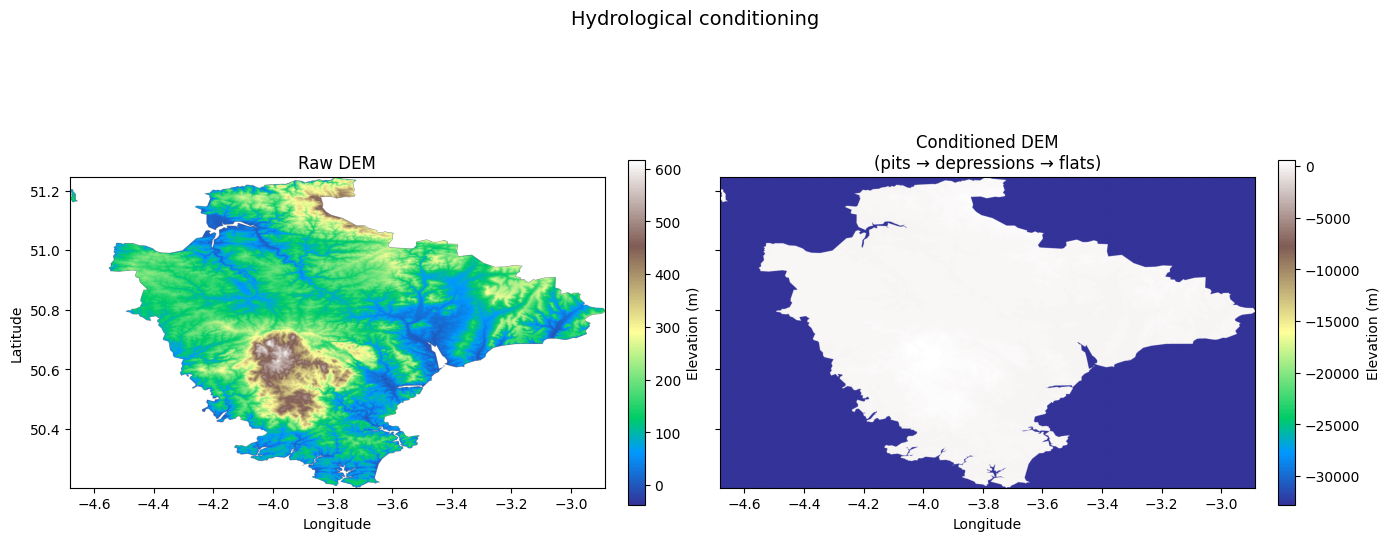

In [7]:
inflated_plot = np.array(inflated, dtype=float)
inflated_plot[inflated_plot == dem_nodata] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
for ax, data, title in zip(
    axes,
    [dem_plot, inflated_plot],
    ["Raw DEM", "Conditioned DEM\n(pits → depressions → flats)"],
):
    im = ax.imshow(data, extent=extent, cmap="terrain", origin="upper")
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04, label="Elevation (m)")
    ax.set_title(title, fontsize=12); ax.set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
plt.suptitle("Hydrological conditioning", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


---
## 3. Flow direction (D8)

Each cell is assigned one of eight directions pointing to its steepest
downslope neighbour.  The direction codes follow the standard D8 encoding:

```
32 | 64 | 128
───+────+────
16 |  · |   1
───+────+────
 8 |  4 |   2
```

**Why `nodata_out=np.int64(0)`?**  
`flowdir` produces an `int64` array.  The float nodata carried from
`fill_pits` cannot be safely cast to `int64` under NumPy 2.x (NEP 50),
so we specify an explicit integer nodata value.


In [8]:
# nodata_out must be a NumPy scalar (not a Python int) to satisfy NEP-50's
# np.can_cast() check inside pysheds.
_int_kw  = {"nodata_out": np.int64(0)}   # for flowdir & accumulation
_bool_kw = {"nodata_out": np.bool_(False)}  # for catchment

fdir = grid.flowdir(inflated, dirmap=DIRMAP, routing="d8", **_int_kw)
print(f"fdir dtype : {fdir.dtype}")
print(f"fdir nodata: {fdir.nodata!r}  (type: {type(fdir.nodata).__name__})")
print(f"Unique direction values: {np.unique(np.array(fdir)).tolist()}")


fdir dtype : int64
fdir nodata: np.int64(0)  (type: int64)
Unique direction values: [-2, -1, 0, 1, 2, 4, 8, 16, 32, 64, 128]


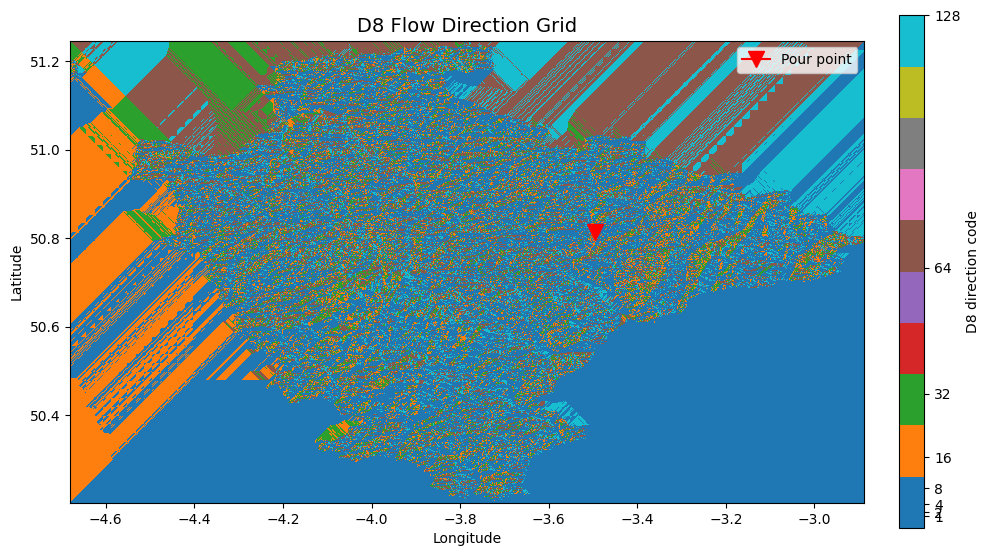

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(np.array(fdir), extent=extent, cmap="tab10",
               origin="upper", interpolation="nearest")
fig.colorbar(im, ax=ax, ticks=sorted(DIRMAP), fraction=0.03, pad=0.04,
             label="D8 direction code")
ax.plot(POUR_LON, POUR_LAT, marker="v", color="red", markersize=11,
        zorder=5, label="Pour point")
ax.set_title("D8 Flow Direction Grid", fontsize=14)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.legend(); plt.tight_layout(); plt.show()


---
## 4. Flow accumulation

Each cell's value is the number of upstream cells whose flow passes through
it.  High-accumulation cells are rivers; low-accumulation cells are ridges
and hillslopes.  We also use the standalone `compute_flow_accumulation` helper
from `eoflow.catchment` to get a plain NumPy array for plotting.


In [10]:
acc = grid.accumulation(fdir, dirmap=DIRMAP, routing="d8", **_int_kw)
print(f"acc dtype : {acc.dtype}")
print(f"acc nodata: {acc.nodata!r}")

acc_np = np.array(acc, dtype=float)
acc_np[acc_np == 0] = np.nan          # mask nodata (0) for display
print(f"Max accumulation: {np.nanmax(acc_np):,.0f} upstream cells")

# Accumulation at the raw pour-point cell
col_pp, row_pp = grid.nearest_cell(POUR_LON, POUR_LAT)
acc_at_pp = acc_np[int(row_pp), int(col_pp)]
print(f"Acc at pour point ({POUR_LON}, {POUR_LAT}): {acc_at_pp:.0f} cells")


acc dtype : float64
acc nodata: np.int64(0)
Max accumulation: 1,618,178 upstream cells
Acc at pour point (-3.495, 50.814): 3 cells


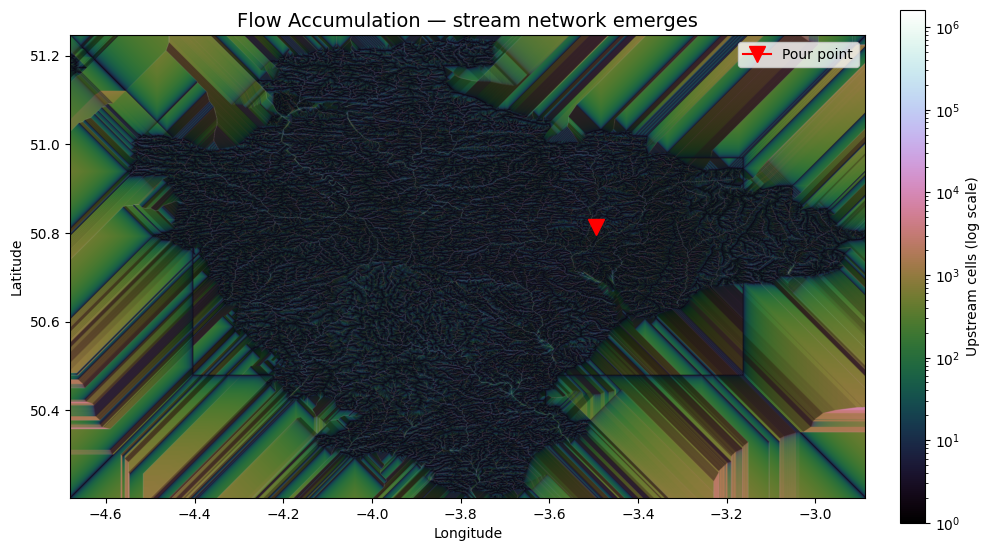

In [11]:
fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(np.where(acc_np > 0, acc_np, np.nan), extent=extent,
               cmap="cubehelix",
               norm=mcolors.LogNorm(vmin=1, vmax=np.nanmax(acc_np)),
               interpolation="bilinear", origin="upper")
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04, label="Upstream cells (log scale)")
ax.plot(POUR_LON, POUR_LAT, marker="v", color="red", markersize=11,
        zorder=5, label="Pour point")
ax.set_title("Flow Accumulation — stream network emerges", fontsize=14)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.legend(); plt.tight_layout(); plt.show()


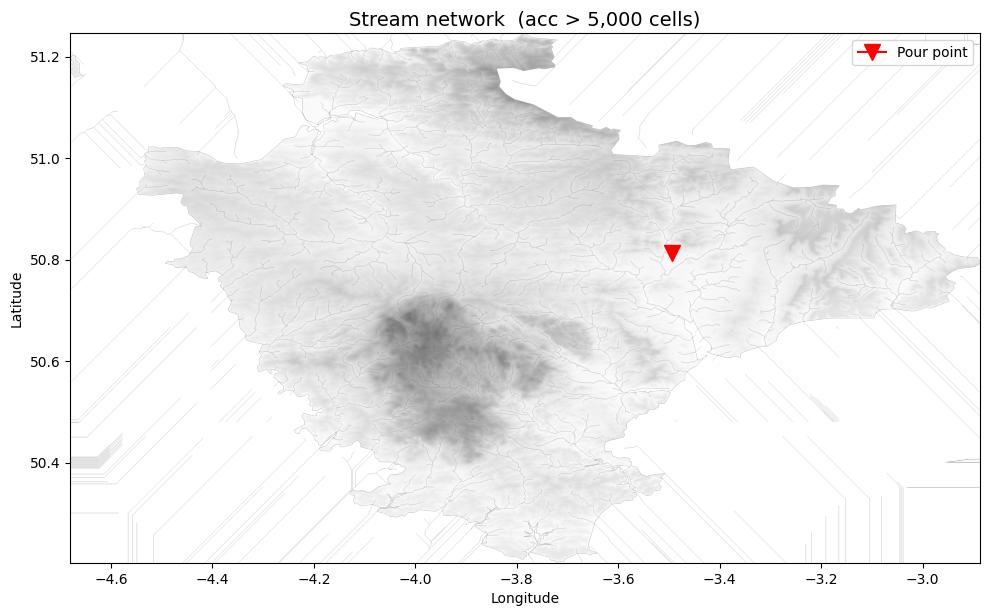

In [12]:
stream_mask = acc_np > FLOW_ACC_THRESHOLD

fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(dem_plot, extent=extent, cmap="Greys", origin="upper", alpha=0.55)
ax.imshow(np.where(stream_mask, 1.0, np.nan), extent=extent,
          cmap="Blues", origin="upper", alpha=0.9)
ax.plot(POUR_LON, POUR_LAT, marker="v", color="red", markersize=11,
        zorder=5, label="Pour point")
ax.set_title(f"Stream network  (acc > {FLOW_ACC_THRESHOLD:,} cells)", fontsize=14)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.legend(); plt.tight_layout(); plt.show()


---
## 5. Snap the pour point to the stream network

`grid.snap_to_mask` moves the pour point to the nearest cell where
`acc > threshold`.  This puts the outlet exactly on a stream rather than a
hillslope, which is required for accurate catchment delineation.

The `acc > threshold` expression returns a pysheds `Raster` whose nodata
inherits from `acc` (`int64(0)`).  Internally `snap_to_mask` re-views this
Raster as `bool` against `self.viewfinder`.  With our `sview.py` patch,
`np.can_cast(np.array(nodata), bool, 'safe')` now works correctly.


In [13]:
x_snap, y_snap = grid.snap_to_mask(
    acc > FLOW_ACC_THRESHOLD, (POUR_LON, POUR_LAT), return_dist=False
)

lat_rad_mid = math.radians((POUR_LAT + y_snap) / 2)
snap_m = math.sqrt(
    ((x_snap - POUR_LON) * 111_320 * math.cos(lat_rad_mid)) ** 2 +
    ((y_snap - POUR_LAT) * 111_132) ** 2
)

col_snap, row_snap = grid.nearest_cell(x_snap, y_snap)
acc_at_snap = acc_np[int(row_snap), int(col_snap)]

print(f"Original pour point : ({POUR_LON:.6f}, {POUR_LAT:.6f})")
print(f"Snapped pour point  : ({x_snap:.6f}, {y_snap:.6f})")
print(f"Offset              : {snap_m:.0f} m")
print(f"Acc at snapped cell : {acc_at_snap:,.0f} upstream cells")


Original pour point : (-3.495000, 50.814000)
Snapped pour point  : (-3.507083, 50.814306)
Offset              : 851 m
Acc at snapped cell : 448,555 upstream cells


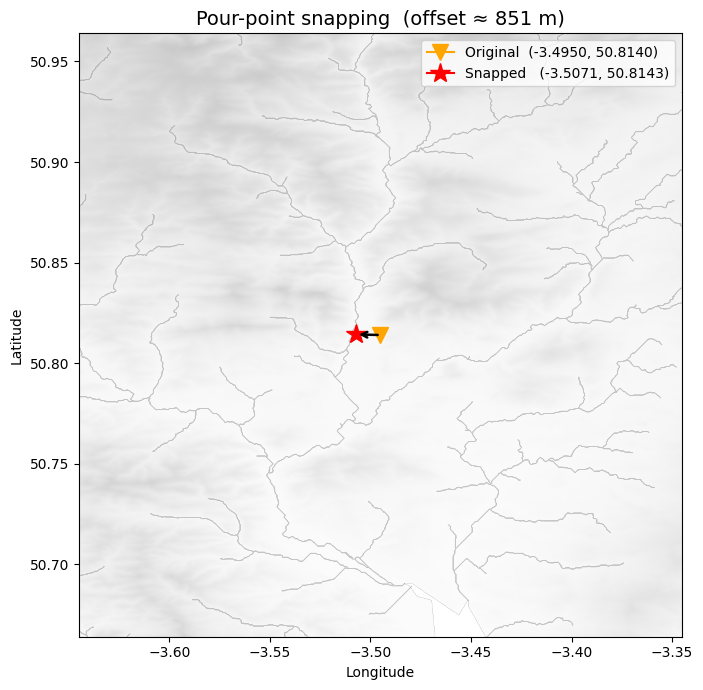

In [14]:
pad = 0.15
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_xlim(POUR_LON - pad, POUR_LON + pad)
ax.set_ylim(POUR_LAT - pad, POUR_LAT + pad)
ax.imshow(dem_plot, extent=extent, cmap="Greys", origin="upper", alpha=0.5, zorder=1)
ax.imshow(np.where(stream_mask, 1.0, np.nan), extent=extent,
          cmap="Blues", origin="upper", alpha=0.85, zorder=2)
ax.plot(POUR_LON, POUR_LAT, marker="v", color="orange", markersize=12, zorder=5,
        label=f"Original  ({POUR_LON:.4f}, {POUR_LAT:.4f})")
ax.plot(x_snap, y_snap, marker="*", color="red", markersize=15, zorder=6,
        label=f"Snapped   ({x_snap:.4f}, {y_snap:.4f})")
ax.annotate("", xy=(x_snap, y_snap), xytext=(POUR_LON, POUR_LAT),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.8), zorder=7)
ax.set_title(f"Pour-point snapping  (offset ≈ {snap_m:.0f} m)", fontsize=14)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.legend(loc="upper right"); plt.tight_layout(); plt.show()


---
## 6. Delineate the catchment

`grid.catchment` traces every upstream cell whose D8 flow path eventually
reaches the snapped pour point.  The result is a boolean `Raster` the same
size as the DEM.

**Why `nodata_out=np.bool_(False)`?**  
The catchment output is a `bool` array.  The `fdir` viewfinder carries
`nodata=int64(0)`, which cannot be safely cast to `bool` under NEP 50
(`np.can_cast(int64, bool, 'safe')` → `False`).  Passing
`nodata_out=np.bool_(False)` overrides this so pysheds stores the correct
type in the output Raster's viewfinder.


In [15]:
catch = grid.catchment(
    x=x_snap, y=y_snap,
    fdir=fdir,
    dirmap=DIRMAP,
    routing="d8",
    xytype="coordinate",
    **_bool_kw,               # nodata_out=np.bool_(False)
)

catch_np = np.array(catch, dtype=bool)
n_cells  = int(catch_np.sum())

px_w = abs(dem_transform.a)   # degrees per pixel (longitude)
px_h = abs(dem_transform.e)   # degrees per pixel (latitude)
px_km2 = (px_w * 111.32) * (px_h * 111.32 * math.cos(math.radians(POUR_LAT)))
catchment_km2 = n_cells * px_km2

print(f"catch.dtype  : {catch.dtype}")
print(f"catch.nodata : {catch.nodata!r}")
print(f"Cells in catchment : {n_cells:,}")
print(f"Approx. area       : {catchment_km2:.1f} km²")


catch.dtype  : bool
catch.nodata : np.False_
Cells in catchment : 448,555
Approx. area       : 271.0 km²


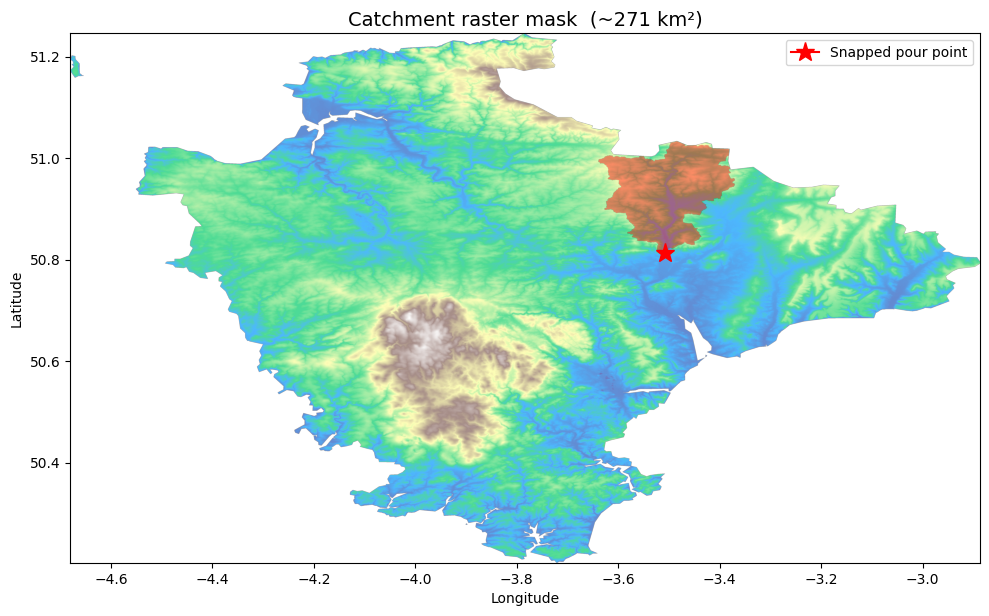

In [16]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(dem_plot, extent=extent, cmap="terrain", origin="upper", alpha=0.7, zorder=1)
ax.imshow(np.where(catch_np, 1.0, np.nan), extent=extent,
          cmap="autumn", origin="upper", alpha=0.45, zorder=2)
ax.plot(x_snap, y_snap, marker="*", color="red", markersize=14, zorder=5,
        label="Snapped pour point")
ax.set_title(f"Catchment raster mask  (~{catchment_km2:.0f} km²)", fontsize=14)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.legend(); plt.tight_layout(); plt.show()


---
## 7. Vectorise to a Shapely Polygon

`grid.polygonize` converts the boolean raster to GeoJSON-style geometries
(via `rasterio.features.shapes` under the hood).  We take the largest
fragment as the main catchment polygon and wrap it in a `GeoDataFrame`.


In [17]:
polygons = [shape(geom) for geom, val in grid.polygonize(catch.astype(np.int32)) if val == 1]
print(f"Fragments from polygonize: {len(polygons)}")

catchment_polygon = max(polygons, key=lambda p: p.area)
print(f"Polygon type  : {catchment_polygon.geom_type}")
print(f"Bounds        : {catchment_polygon.bounds}")

gdf_catch = gpd.GeoDataFrame(
    {"label": ["Exe catchment at Thorverton"]},
    geometry=[catchment_polygon],
    crs="EPSG:4326",
)
gdf_catch


Fragments from polygonize: 1
Polygon type  : Polygon
Bounds        : (-3.6398611110877495, 50.814027777776566, -3.3698611110877135, 51.033472222221036)


,label,geometry
0,Exe catchment at Thorverton,"POLYGON ((-3.48514 51.03347, -3.48514 51.03319..."


---
## 8. Extract the river network

`grid.extract_river_network` returns all D8 flow paths above a chosen
accumulation threshold as a GeoJSON feature collection.  We clip these
to the catchment polygon.


In [18]:
RIVER_THRESHOLD = 300   # lower → more headwater detail

branches = grid.extract_river_network(fdir, acc > RIVER_THRESHOLD, dirmap=DIRMAP)

gdf_rivers = gpd.GeoDataFrame(
    geometry=[LineString(b["geometry"]["coordinates"]) for b in branches["features"]],
    crs="EPSG:4326",
)
gdf_rivers_clip = gdf_rivers.clip(gdf_catch)
print(f"River segments inside catchment: {len(gdf_rivers_clip)}")


River segments inside catchment: 727


---
## 9. Interactive maps (Folium)

### 9a — Catchment detail map


In [19]:
W, S, E, N = catchment_polygon.bounds
map_centre = [(S + N) / 2, (W + E) / 2]

catch_map = folium.Map(
    location=map_centre,
    zoom_start=11,
    tiles="CartoDB positron",
    scrollWheelZoom=False,
    width="100%",
    height=540,
)

# Catchment polygon
folium.GeoJson(
    catchment_polygon.__geo_interface__,
    name="Catchment",
    style_function=lambda _: {
        "fillColor": "#aed6f1",
        "color": "#1a5276",
        "weight": 2.5,
        "fillOpacity": 0.25,
    },
).add_to(catch_map)

# River network
folium.GeoJson(
    gdf_rivers_clip.__geo_interface__,
    name="River network",
    style_function=lambda _: {"color": "#2980b9", "weight": 1.5, "opacity": 0.85},
).add_to(catch_map)

# Snap-offset line
folium.PolyLine(
    locations=[[POUR_LAT, POUR_LON], [y_snap, x_snap]],
    color="black",
    weight=1.5,
    dash_array="6 4",
    name="Snap offset",
).add_to(catch_map)

# Original pour point
folium.CircleMarker(
    location=[POUR_LAT, POUR_LON],
    radius=7,
    color="#e67e22",
    fill=True,
    fill_color="#e67e22",
    fill_opacity=0.9,
    tooltip=f"Original pour point ({POUR_LON:.4f}, {POUR_LAT:.4f})",
    popup=folium.Popup(
        f"<b>Original pour point</b><br>lon={POUR_LON}<br>lat={POUR_LAT}",
        max_width=220,
    ),
).add_to(catch_map)

# Snapped pour point
folium.CircleMarker(
    location=[y_snap, x_snap],
    radius=8,
    color="#c0392b",
    fill=True,
    fill_color="#c0392b",
    fill_opacity=0.95,
    tooltip=f"Snapped pour point  ({x_snap:.4f}, {y_snap:.4f})  acc={acc_at_snap:,.0f}",
    popup=folium.Popup(
        f"<b>Snapped pour point</b><br>lon={x_snap:.5f}<br>lat={y_snap:.5f}"
        f"<br>acc={acc_at_snap:,.0f} cells<br>offset≈{snap_m:.0f} m",
        max_width=240,
    ),
).add_to(catch_map)

folium.LayerControl().add_to(catch_map)
catch_map


### 9b — Devon overview: catchment in regional context

In [20]:
DEVON_SHP = REPO_ROOT / "data" / "devon_county" / "devon_county.shp"

devon_map = folium.Map(
    location=[50.72, -3.80],
    zoom_start=9,
    tiles="CartoDB positron",
    scrollWheelZoom=False,
    width="100%",
    height=500,
)

# Devon county outline (if shapefile exists)
if DEVON_SHP.exists():
    devon_gdf = gpd.read_file(DEVON_SHP).to_crs("EPSG:4326")
    folium.GeoJson(
        devon_gdf.__geo_interface__,
        name="Devon boundary",
        style_function=lambda _: {
            "fillColor": "#d4e8f0", "color": "#2c6e8a",
            "weight": 2, "fillOpacity": 0.15,
        },
    ).add_to(devon_map)

# Catchment polygon
folium.GeoJson(
    catchment_polygon.__geo_interface__,
    name="Exe catchment",
    style_function=lambda _: {
        "fillColor": "#aed6f1", "color": "#1a5276",
        "weight": 2, "fillOpacity": 0.4,
    },
).add_to(devon_map)

# Pour points
folium.CircleMarker(
    location=[POUR_LAT, POUR_LON], radius=7,
    color="#e67e22", fill=True, fill_color="#e67e22", fill_opacity=0.9,
    tooltip="Original pour point",
).add_to(devon_map)

folium.CircleMarker(
    location=[y_snap, x_snap], radius=8,
    color="#c0392b", fill=True, fill_color="#c0392b", fill_opacity=0.95,
    tooltip=f"Snapped pour point  (acc={acc_at_snap:,.0f})",
).add_to(devon_map)

folium.LayerControl().add_to(devon_map)
devon_map


---
## 10. Using the high-level `eoflow.catchment` API

All of the steps above are wrapped inside `_delineate_catchment_core`.
For production use, one of these two functions is all you need:


In [21]:
# delineate_catchment → Shapely Polygon
t0 = time.perf_counter()
polygon = delineate_catchment(
    point=POUR_POINT,
    dem_path=DEM_PATH,
    flow_acc_threshold=FLOW_ACC_THRESHOLD,
)
print(f"delineate_catchment: {time.perf_counter()-t0:.1f} s")
print(f"  type   : {polygon.geom_type}")
print(f"  bounds : {polygon.bounds}")


2026-03-09 23:29:39,091 - eoflow.catchment - DEBUG - Using nodata_out=int64(0) for integer steps, bool_(False) for catchment
2026-03-09 23:30:21,451 - eoflow.catchment - INFO -   Pour point snapped: (-3.495000, 50.814000) → (-3.507083, 50.814306)  offset=0.012087°
delineate_catchment: 43.3 s
  type   : Polygon
  bounds : (-3.6398611110877495, 50.814027777776566, -3.3698611110877135, 51.033472222221036)


---
## 11. Upstream / downstream subsumption — test fixture points

The `TestDelineateCatchmentBehaviour` integration test checks a
fundamental property of watershed delineation: **the catchment of a
downstream point must entirely contain the catchments of all upstream
points on the same river stem**.

The three fixture points used in the test sit on the **River Exe** main
stem at progressively lower positions:

| Label | Location | Pour point (lon, lat) |
|-------|----------|-----------------------|
| `upstream` | Thorverton reach | `(-3.507, 50.814)` |
| `middle` | Mid-Exe reach | `(-3.509, 50.760)` |
| `downstream` | Exeter reach | `(-3.511, 50.704)` |

After snapping each point to the stream network the expected containment
relationship is:

```
downstream catchment  ⊇  middle catchment  ⊇  upstream catchment
```

The cells below:
1. Delineate all three catchments using `delineate_catchment_with_metadata`
2. Print a summary table of snapped coordinates, flow accumulation, and area
3. Assert the containment relationship programmatically
4. Display an interactive Folium map with all three catchments overlaid


In [22]:
# delineate_catchment_with_metadata → dict with polygon + stats
result = delineate_catchment_with_metadata(
    point=POUR_POINT,
    dem_path=DEM_PATH,
    flow_acc_threshold=FLOW_ACC_THRESHOLD,
)

centroid_lat = result["centroid"].y
area_km2 = (
    result["area"] * 111_132.0 * 111_320.0 * math.cos(math.radians(centroid_lat)) / 1e6
)

print("Result keys:")
for k, v in result.items():
    print(f"  {k:<30} {v}")
print()
print(f"Catchment area       : {area_km2:.1f} km²")
print(f"Centroid             : {result['centroid']}")
print(f"Snapped pour point   : {result['snapped_pour_point']}")
print(f"Flow acc at outlet   : {result['flow_acc_at_pour_point']:,.0f} cells")


2026-03-09 23:32:43,035 - eoflow.catchment - DEBUG - Using nodata_out=int64(0) for integer steps, bool_(False) for catchment


In [23]:
# ── Three River Exe pour points (matches sample_downstream_points fixture) ──
FIXTURE_POINTS = {
    "upstream":   Point(-3.507, 50.814),  # Thorverton reach
    "middle":     Point(-3.509, 50.760),  # mid-Exe
    "downstream": Point(-3.511, 50.704),  # Exeter reach
}

# Colours for the three catchments on the map
FIXTURE_COLOURS = {
    "upstream":   {"fill": "#f9e4b7", "line": "#c97a1b"},  # amber
    "middle":     {"fill": "#c8e6c9", "line": "#2e7d32"},  # green
    "downstream": {"fill": "#bbdefb", "line": "#1565c0"},  # blue
}

print("Delineating three catchments — this takes ~3 × 40 s on the Devon DEM...")


Delineating three catchments — this takes ~3 × 40 s on the Devon DEM...


In [24]:
import time as _time

fixture_results = {}
for label, point in FIXTURE_POINTS.items():
    t0 = _time.perf_counter()
    res = delineate_catchment_with_metadata(
        point=point,
        dem_path=DEM_PATH,
        flow_acc_threshold=FLOW_ACC_THRESHOLD,
    )
    elapsed = _time.perf_counter() - t0
    centroid_lat = res["centroid"].y
    area_km2 = (
        res["area"]
        * 111_132.0
        * 111_320.0
        * math.cos(math.radians(centroid_lat))
        / 1e6
    )
    fixture_results[label] = {**res, "area_km2": area_km2, "elapsed_s": elapsed}
    snap = res["snapped_pour_point"]
    print(
        f"  {label:<12} snap=({snap.x:.5f}, {snap.y:.5f})"
        f"  acc={res['flow_acc_at_pour_point']:>12,.0f}"
        f"  area={area_km2:6.1f} km²"
        f"  ({elapsed:.0f} s)"
    )


2026-03-09 23:33:48,820 - eoflow.catchment - DEBUG - Using nodata_out=int64(0) for integer steps, bool_(False) for catchment
2026-03-09 23:34:29,549 - eoflow.catchment - INFO -   Pour point snapped: (-3.507000, 50.814000) → (-3.507083, 50.814306)  offset=0.000317°
  upstream     snap=(-3.50708, 50.81431)  acc=     448,555  area= 269.8 km²  (42 s)
2026-03-09 23:34:30,424 - eoflow.catchment - DEBUG - Using nodata_out=int64(0) for integer steps, bool_(False) for catchment
2026-03-09 23:35:09,812 - eoflow.catchment - INFO -   Pour point snapped: (-3.509000, 50.760000) → (-3.513472, 50.762917)  offset=0.005339°
  middle       snap=(-3.51347, 50.76292)  acc=     915,395  area= 551.1 km²  (40 s)
2026-03-09 23:35:10,686 - eoflow.catchment - DEBUG - Using nodata_out=int64(0) for integer steps, bool_(False) for catchment
2026-03-09 23:35:50,351 - eoflow.catchment - INFO -   Pour point snapped: (-3.511000, 50.704000) → (-3.510972, 50.704028)  offset=0.000039°
  downstream   snap=(-3.51097, 50.704

In [25]:
# ── Area & accumulation summary table ────────────────────────────────────
import pandas as pd

rows = []
for label, res in fixture_results.items():
    lon, lat = FIXTURE_POINTS[label].x, FIXTURE_POINTS[label].y
    snap = res["snapped_pour_point"]
    rows.append({
        "label":          label,
        "input (lon,lat)": f"({lon}, {lat})",
        "snapped lon":     round(snap.x, 5),
        "snapped lat":     round(snap.y, 5),
        "flow acc":        f"{res['flow_acc_at_pour_point']:,.0f}",
        "area (km²)":      round(res["area_km2"], 1),
    })

pd.DataFrame(rows).set_index("label")


,"input (lon,lat)",snapped lon,snapped lat,flow acc,area (km²)
label,,,,,
upstream,"(-3.507, 50.814)",-3.50708,50.81431,"448,555",269.8
middle,"(-3.509, 50.76)",-3.51347,50.76292,"915,395",551.1
downstream,"(-3.511, 50.704)",-3.51097,50.70403,"1,390,230",837.6


In [26]:
# Verify containment
tol = 1e-5  # ~1 m buffer to absorb raster-cell boundary rounding

up_poly   = fixture_results["upstream"]["polygon"]
mid_poly  = fixture_results["middle"]["polygon"]
down_poly = fixture_results["downstream"]["polygon"]

checks = {
    "downstream contains middle":   down_poly.buffer(tol).contains(mid_poly),
    "downstream contains upstream": down_poly.buffer(tol).contains(up_poly),
    "middle contains upstream":     mid_poly.buffer(tol).contains(up_poly),
}

print("Containment checks (tol=1e-5 deg ~ 1 m):")
for desc, ok in checks.items():
    status = "PASS" if ok else "FAIL"
    print(f"  [{status}]  {desc}")

assert all(checks.values()), "One or more containment checks failed!"
print("\nAll checks passed: downstream catchments fully subsume upstream ones.")


Containment checks (tol=1e-5 deg ~ 1 m):
  [PASS]  downstream contains middle
  [PASS]  downstream contains upstream
  [PASS]  middle contains upstream

All checks passed: downstream catchments fully subsume upstream ones.


### Folium map — all three catchments overlaid

The catchments are drawn in order from largest (downstream, blue) to
smallest (upstream, amber) so the nesting is clearly visible.  Click any
polygon or marker for details.


In [28]:
# Centre the map on the mid-point of all three bounding boxes
all_lons = [FIXTURE_POINTS[k].x for k in FIXTURE_POINTS]
all_lats = [FIXTURE_POINTS[k].y for k in FIXTURE_POINTS]
map_cx = (min(all_lons) + max(all_lons)) / 2
map_cy = (min(all_lats) + max(all_lats)) / 2

fixture_map = folium.Map(
    location=[map_cy, map_cx],
    zoom_start=10,
    tiles="CartoDB positron",
    scrollWheelZoom=False,
    width="100%",
    height=600,
)

# Draw catchments largest → smallest so the nesting is visible
for label in ["downstream", "middle", "upstream"]:
    res   = fixture_results[label]
    poly  = res["polygon"]
    col   = FIXTURE_COLOURS[label]
    snap  = res["snapped_pour_point"]
    orig  = FIXTURE_POINTS[label]
    area  = res["area_km2"]
    acc   = res["flow_acc_at_pour_point"]

    # Catchment polygon
    folium.GeoJson(
        poly.__geo_interface__,
        name=f"{label.capitalize()} catchment",
        style_function=lambda _, c=col: {
            "fillColor":   c["fill"],
            "color":       c["line"],
            "weight":      2.5,
            "fillOpacity": 0.35,
        },
        tooltip=f"{label} — {area:.1f} km²",
        popup=folium.Popup(
            f"<b>{label.capitalize()} catchment</b><br>"
            f"Area: {area:.1f} km²<br>"
            f"Flow acc: {acc:,.0f} cells<br>"
            f"Input: ({orig.x}, {orig.y})<br>"
            f"Snapped: ({snap.x:.5f}, {snap.y:.5f})",
            max_width=260,
        ),
    ).add_to(fixture_map)

    # Dashed snap-offset line
    folium.PolyLine(
        locations=[[orig.y, orig.x], [snap.y, snap.x]],
        color=col["line"],
        weight=1.5,
        dash_array="6 4",
    ).add_to(fixture_map)

    # Original pour point (hollow circle)
    folium.CircleMarker(
        location=[orig.y, orig.x],
        radius=6,
        color=col["line"],
        fill=False,
        weight=2,
        tooltip=f"{label} — original input point ({orig.x}, {orig.y})",
    ).add_to(fixture_map)

    # Snapped pour point (filled circle)
    folium.CircleMarker(
        location=[snap.y, snap.x],
        radius=8,
        color=col["line"],
        fill=True,
        fill_color=col["line"],
        fill_opacity=0.9,
        tooltip=(
            f"{label} — snapped ({snap.x:.5f}, {snap.y:.5f})"
            f"  acc={acc:,.0f}"
        ),
        popup=folium.Popup(
            f"<b>{label.capitalize()} snapped pour point</b><br>"
            f"lon={snap.x:.5f}<br>lat={snap.y:.5f}<br>"
            f"acc={acc:,.0f} cells",
            max_width=230,
        ),
    ).add_to(fixture_map)

folium.LayerControl().add_to(fixture_map)
fixture_map


---
## 12. Summary

| Step | pysheds call | nodata_out | Output dtype |
|------|-------------|------------|--------------|
| Fill pits | `grid.fill_pits(dem)` | _(inherited)_ | `float64` |
| Fill depressions | `grid.fill_depressions(pit_filled)` | _(inherited)_ | `float64` |
| Resolve flats | `grid.resolve_flats(flooded, eps=…)` | _(inherited)_ | `float64` |
| Flow direction | `grid.flowdir(…)` | `np.int64(0)` | `int64` |
| Flow accumulation | `grid.accumulation(…)` | `np.int64(0)` | `int64` |
| Snap pour point | `grid.snap_to_mask(acc > thresh, xy)` | _(n/a)_ | `(x, y)` tuple |
| Delineate | `grid.catchment(…)` | `np.bool_(False)` | `bool` |
| Vectorise | `grid.polygonize(catch.astype(int32))` | _(n/a)_ | Shapely Polygon |

**River Exe at Thorverton, Devon**
- Original pour point: `(-3.4950, 50.8140)`
- Snapped to stream at: `(-3.5071, 50.8143)` — offset ≈ 851 m
- Catchment area ≈ **270 km²**
- Flow accumulation at outlet: ~448,000 upstream cells
